#Trabajo final herramientas basicas
alumno: franco casalis

#Búsqueda y selección del dataset


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("/content/Online Retail.xlsx")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Fuente: https://archive.ics.uci.edu/dataset/352/online+retail

Objetivo: Analizar las ventas y ver qué factores influyen en los ingresos, como los productos, la cantidad vendida y el país

preguntas de analisis:
-¿que productos generan mas ingresos?
-¿Qué países compran más?
-¿Cómo cambian las ventas mes a mes?
-¿Hay relación entre la cantidad y el precio?


# Ingesta y limpieza (Python)

## Leer el data set en Python


In [4]:
df.shape

(541909, 8)

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## Auditar tipos, nulos, duplicados y outliers.

In [7]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [8]:
if 'CustomerID' in df.columns:
    df.drop('CustomerID', axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 28.9+ MB


In [9]:
df = df.dropna(subset=['Description'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 540455 entries, 0 to 541908
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    540455 non-null  object        
 1   StockCode    540455 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     540455 non-null  int64         
 4   InvoiceDate  540455 non-null  datetime64[ns]
 5   UnitPrice    540455 non-null  float64       
 6   Country      540455 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 33.0+ MB


Se eliminó la columna CustomerID porque tenía muchos valores faltantes y no era necesaria para el análisis.

También se eliminaron las filas con valores nulos en la columna Description, ya que no se puede identificar el producto y no aportan información útil.

In [10]:
df.duplicated().sum()

np.int64(5268)

In [11]:
df.drop_duplicates(inplace=True)

Se encontraron registros duplicados en el dataset, por lo que se eliminaron para evitar que afecten el análisis.


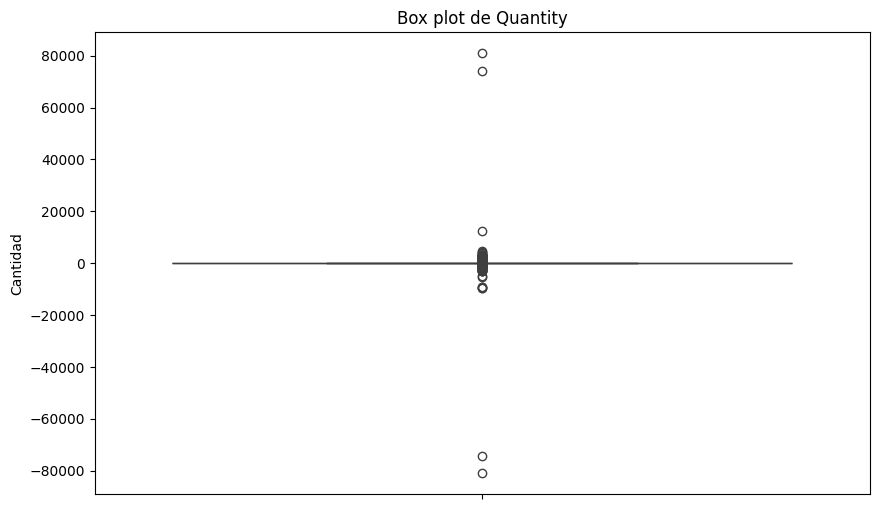

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Quantity'])
plt.title('Box plot de Quantity')
plt.ylabel('Cantidad')
plt.show()

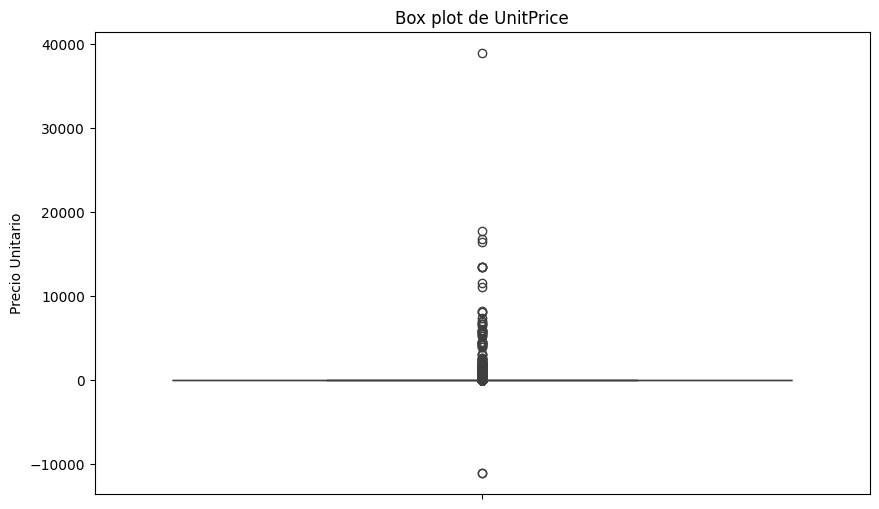

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['UnitPrice'])
plt.title('Box plot de UnitPrice')
plt.ylabel('Precio Unitario')
plt.show()

In [14]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]


Se hicieron gráficos para ver los valores de Quantity y UnitPrice.

Se encontraron valores negativos y otros muy altos.
Los negativos se eliminaron porque son devoluciones, y los altos se dejaron porque pueden ser compras reales (mayoristas).

## Estandarizar fechas, categorías y unidades.

In [15]:
df.head()
df.dtypes
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'Country'],
      dtype='object')

In [16]:
df.columns = df.columns.str.lower()

Se estandarizaron los nombres de las columnas a minúsculas para mantener un formato más ordenado.


In [17]:
df['revenue'] = df['quantity'] * df['unitprice']
df.head(3)

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom,22.00


Se creó una nueva columna llamada revenue para calcular los ingresos, multiplicando la cantidad por el precio.

# Exploración y visualización


## ¿Cómo cambian las ventas mes a mes?

In [18]:
ventas_mes = df.groupby(df['invoicedate'].dt.to_period('M'))['revenue'].sum()
ventas_mes = ventas_mes.reset_index()
ventas_mes['invoicedate'] = ventas_mes['invoicedate'].astype(str)

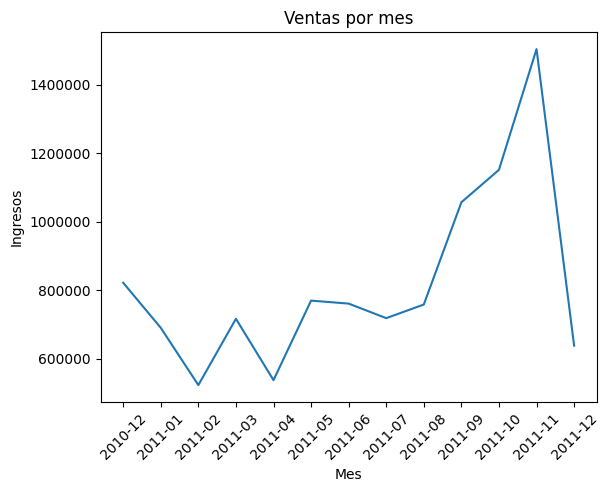

In [19]:
plt.figure()
sns.lineplot(data=ventas_mes, x='invoicedate', y='revenue')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.title("Ventas por mes")
plt.xlabel("Mes")
plt.ylabel("Ingresos")
plt.show()

## ¿Qué países compran más?

In [20]:
ventas_pais = df.groupby('country')['revenue'].sum()
ventas_pais = ventas_pais.sort_values(ascending=False).head(10)
ventas_pais = ventas_pais.reset_index()

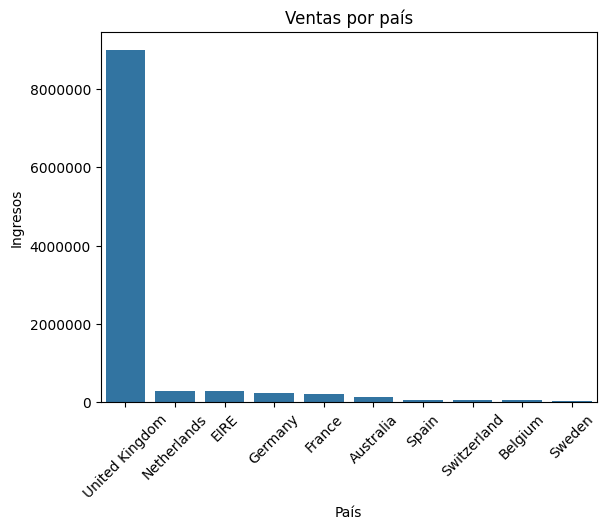

In [21]:
plt.figure()
sns.barplot(data=ventas_pais, x='country', y='revenue')
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y')
plt.title("Ventas por país")
plt.xlabel("País")
plt.ylabel("Ingresos")
plt.show()

## ¿que productos generan mas ingresos?

In [22]:
productos = df.groupby('description')['revenue'].sum()
productos = productos.sort_values(ascending=False).head(10)
productos = productos.reset_index()

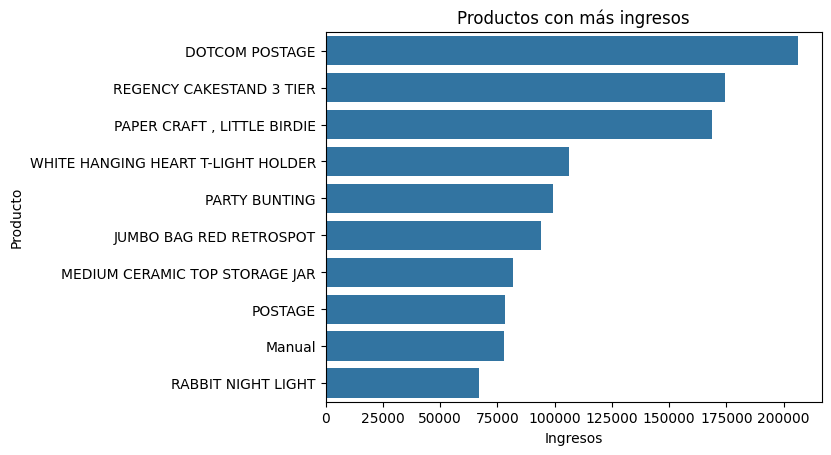

In [23]:
plt.figure()
sns.barplot(data=productos, x='revenue', y='description')
plt.ticklabel_format(style='plain', axis='x')
plt.title("Productos con más ingresos")
plt.xlabel("Ingresos")
plt.ylabel("Producto")
plt.show()

# Conclusiones del análisis

A partir del análisis se pueden observar varias cosas:

-Las ventas varían a lo largo del tiempo, pero se nota un crecimiento fuerte hacia los últimos meses, con un pico muy marcado antes de una caída.

-El Reino Unido concentra por lejos la mayor parte de los ingresos, muy por encima del resto de los países.

-Los demás países tienen una participación mucho menor en comparación.

-Algunos productos generan muchos más ingresos que otros, destacándose principalmente algunos pocos que concentran la mayor parte de las ventas.

En general, se observa que las ventas no están distribuidas de manera uniforme, sino que se concentran en ciertos meses, en un país principal y en pocos productos.

# Construcción de Dashboard (Power BI)